In [1]:
import pandas as pd

# Load the dataset
file_path = '/content/matches_final_curated.csv'
df = pd.read_csv(file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

# Information about data types and missing values
print("\nDataset Information:")
df.info()

# Basic statistical distribution for numerical columns
print("\nStatistical Summary (Numerical Columns):")
display(df.describe())

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")

First 5 rows of the dataset:


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,shootout_winner,...,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,match_outcome,source,fixture_id,league_id,season
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0.0,NaN,...,38.0,1506.77,4.0,1834.12,-327.35,0.0,kaggle,NaN,NaN,NaN
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0.0,NaN,...,4.0,1834.12,38.0,1506.77,327.35,1.0,kaggle,NaN,NaN,NaN
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0.0,NaN,...,38.0,1506.77,4.0,1834.12,-327.35,1.0,kaggle,NaN,NaN,NaN
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0.0,NaN,...,4.0,1834.12,38.0,1506.77,327.35,0.0,kaggle,NaN,NaN,NaN
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0.0,NaN,...,38.0,1506.77,4.0,1834.12,-327.35,1.0,kaggle,NaN,NaN,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50834 entries, 0 to 50833
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 50834 non-null  object 
 1   home_team            50834 non-null  object 
 2   away_team            50834 non-null  object 
 3   home_score           50721 non-null  float64
 4   away_score           50721 non-null  float64
 5   tournament           50834 non-null  object 
 6   city                 48891 non-null  object 
 7   country              48891 non-null  object 
 8   neutral              48891 non-null  float64
 9   shootout_winner      661 non-null    object 
 10  has_shootout         50834 non-null  bool   
 11  goalscorers_rows     50834 non-null  int64  
 12  penalty_goals_count  50834 non-null  int64  
 13  own_goals_count      50834 non-null  int64  
 14  match_key            48891 non-null  object 
 15  home_team_norm

,home_score,away_score,neutral,goalscorers_rows,penalty_goals_count,own_goals_count,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,match_outcome,fixture_id,league_id,season
count,50721.000000,50721.000000,48891.000000,50834.000000,50834.000000,50834.000000,46856.000000,46856.000000,46293.000000,46293.000000,43895.000000,48891.000000,1.943000e+03,1943.000000,1943.000000
mean,1.751503,1.179511,0.263873,0.873923,0.058524,0.016190,74.618277,1374.905284,77.174562,1360.541605,16.017110,0.207666,1.047152e+06,12.398353,2023.014925
std,1.764585,1.397726,0.440736,1.706097,0.262657,0.129894,54.464143,264.650503,54.586334,261.866866,270.111156,0.854219,1.904439e+05,8.932971,0.888932
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,726.030000,1.000000,726.030000,-1151.150000,-1.000000,5.926660e+05,1.000000,2022.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000,1157.220000,32.000000,1149.100000,-158.340000,-1.000000,8.610350e+05,10.000000,2022.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,64.000000,1388.930000,69.000000,1366.020000,20.130000,0.000000,1.035605e+06,10.000000,2023.000000
75%,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,117.000000,1574.010000,120.000000,1553.140000,196.430000,1.000000,1.175760e+06,10.000000,2024.000000
max,31.000000,21.000000,1.000000,31.000000,3.000000,2.000000,210.000000,1877.180000,210.000000,1877.180000,1151.150000,1.000000,1.487929e+06,37.000000,2024.000000



Numerical Columns (15): ['home_score', 'away_score', 'neutral', 'goalscorers_rows', 'penalty_goals_count', 'own_goals_count', 'home_rank_position', 'home_rank_points', 'away_rank_position', 'away_rank_points', 'rank_points_diff', 'match_outcome', 'fixture_id', 'league_id', 'season']
Categorical Columns (11): ['date', 'home_team', 'away_team', 'tournament', 'city', 'country', 'shootout_winner', 'match_key', 'home_team_norm', 'away_team_norm', 'source']


In [2]:
import numpy as np

# 1. Remove duplicate rows
duplicates_count = df.duplicated().sum()
if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f'Removed {duplicates_count} duplicate rows.')

# 2. Calculate missing values percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
print('\nPercentage of missing values per column:\n', missing_percent)

# 3. Remove columns with high percentage of missing values or irrelevant for regression
cols_to_drop = ['shootout_winner', 'fixture_id', 'league_id', 'season', 'match_key']
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# 4. Drop rows with missing target variables
df = df.dropna(subset=['home_score', 'away_score'])

# 5. Impute numerical columns with median
# Specifically focusing on rank positions and points as requested
rank_cols = ['home_rank_position', 'home_rank_points', 'away_rank_position', 'away_rank_points', 'rank_points_diff']
for col in rank_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# 6. Date processing
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

# 7. Final verification
print('\nFinal count of null values:')
print(df.isnull().sum())
print(f'\nFinal shape of the dataset: {df.shape}')
display(df.head())


Percentage of missing values per column:
 date                    0.000000
home_team               0.000000
away_team               0.000000
home_score              0.222292
away_score              0.222292
tournament              0.000000
city                    3.822245
country                 3.822245
neutral                 3.822245
shootout_winner        98.699689
has_shootout            0.000000
goalscorers_rows        0.000000
penalty_goals_count     0.000000
own_goals_count         0.000000
match_key               3.822245
home_team_norm          0.000000
away_team_norm          0.000000
home_rank_position      7.825471
home_rank_points        7.825471
away_rank_position      8.932998
away_rank_points        8.932998
rank_points_diff       13.650313
match_outcome           3.822245
source                  0.000000
fixture_id             96.177755
league_id              96.177755
season                 96.177755
dtype: float64

Final count of null values:
date                  

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,has_shootout,...,home_team_norm,away_team_norm,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,match_outcome,source,year
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,0.0,False,...,Scotland,England,38.0,1506.77,4.0,1834.12,-327.35,0.0,kaggle,1872
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,0.0,False,...,England,Scotland,4.0,1834.12,38.0,1506.77,327.35,1.0,kaggle,1873
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,0.0,False,...,Scotland,England,38.0,1506.77,4.0,1834.12,-327.35,1.0,kaggle,1874
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,0.0,False,...,England,Scotland,4.0,1834.12,38.0,1506.77,327.35,0.0,kaggle,1875
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,0.0,False,...,Scotland,England,38.0,1506.77,4.0,1834.12,-327.35,1.0,kaggle,1876


In [3]:
# 1. Ensure 'has_shootout' and 'neutral' are 0 and 1
df['has_shootout'] = df['has_shootout'].astype(int)
df['neutral'] = df['neutral'].fillna(0).astype(int)

# 2. One-Hot Encoding for 'tournament' with drop_first=True to avoid multicollinearity
tournament_dummies = pd.get_dummies(df['tournament'], prefix='tourn', drop_first=True)

# 3. Combine dummies with original dataframe
df_encoded = pd.concat([df, tournament_dummies], axis=1)

# 4. Define feature set and targets
# Including ranking variables, year, neutrality, and encoded tournament features
rank_features = ['home_rank_position', 'home_rank_points', 'away_rank_position', 'away_rank_points', 'rank_points_diff']
other_features = ['year', 'neutral', 'has_shootout']
tournament_features = tournament_dummies.columns.tolist()

features = rank_features + other_features + tournament_features
targets = ['home_score', 'away_score']

# 5. Create the final modeling DataFrame
df_final = df_encoded[features + targets]

# 6. Verify all columns are numeric and display head
print(f'Shape of final DataFrame: {df_final.shape}')
print('\nNon-numeric columns check:', df_final.select_dtypes(exclude=[np.number]).columns.tolist())
display(df_final.head())

Shape of final DataFrame: (50721, 204)

Non-numeric columns check: ['tourn_AFC Asian Cup', 'tourn_AFC Asian Cup qualification', 'tourn_AFC Challenge Cup', 'tourn_AFC Challenge Cup qualification', 'tourn_AFF Championship', 'tourn_AFF Championship qualification', 'tourn_ASEAN Championship', 'tourn_ASEAN Championship qualification', 'tourn_African Cup of Nations', 'tourn_African Cup of Nations qualification', 'tourn_African Friendship Games', 'tourn_Afro-Asian Games', 'tourn_Al Ain International Cup', 'tourn_All-African Games', 'tourn_Amílcar Cabral Cup', 'tourn_Arab Cup', 'tourn_Arab Cup qualification', 'tourn_Asian Games', 'tourn_Atlantic Cup', 'tourn_Atlantic Heritage Cup', 'tourn_Balkan Cup', 'tourn_Baltic Cup', 'tourn_Beijing International Friendship Tournament', 'tourn_Benedikt Fontana Cup', 'tourn_Bolivarian Games', 'tourn_Brazil Independence Cup', 'tourn_British Home Championship', 'tourn_CAFA Nations Cup', 'tourn_CCCF Championship', 'tourn_CECAFA Cup', 'tourn_CFU Caribbean Cup', 

,home_rank_position,home_rank_points,away_rank_position,away_rank_points,rank_points_diff,year,neutral,has_shootout,tourn_AFC Asian Cup,tourn_AFC Asian Cup qualification,...,tourn_Windward Islands Tournament,tourn_World Cup,tourn_World Cup - Qualification CONCACAF,tourn_World Cup - Qualification Europe,tourn_World Cup - Qualification Intercontinental Play-offs,tourn_World Unity Cup,tourn_Zambian Independence Tournament,tourn_Évence Coppée Trophy,home_score,away_score
0,38.0,1506.77,4.0,1834.12,-327.35,1872,0,0,False,False,...,False,False,False,False,False,False,False,False,0.0,0.0
1,4.0,1834.12,38.0,1506.77,327.35,1873,0,0,False,False,...,False,False,False,False,False,False,False,False,4.0,2.0
2,38.0,1506.77,4.0,1834.12,-327.35,1874,0,0,False,False,...,False,False,False,False,False,False,False,False,2.0,1.0
3,4.0,1834.12,38.0,1506.77,327.35,1875,0,0,False,False,...,False,False,False,False,False,False,False,False,2.0,2.0
4,38.0,1506.77,4.0,1834.12,-327.35,1876,0,0,False,False,...,False,False,False,False,False,False,False,False,3.0,0.0


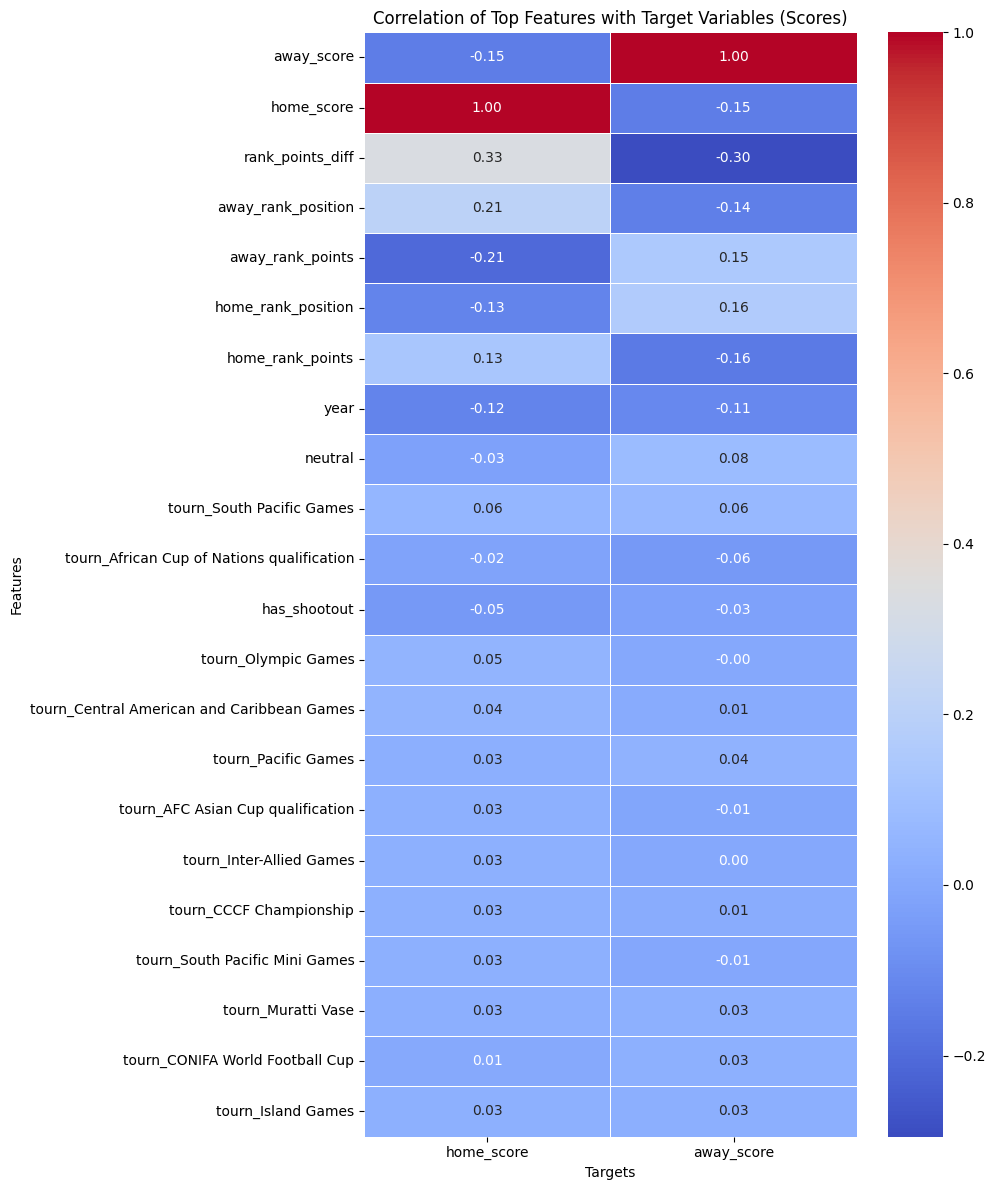

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlation matrix
corr_matrix = df_final.corr()

# 2. Filter correlations for the target variables
target_corr = corr_matrix[['home_score', 'away_score']]

# 3. Since there are >200 columns, let's identify the most relevant features to keep the heatmap legible
# We will take the top 20 features with highest absolute correlation with either home_score or away_score
top_features = target_corr.abs().max(axis=1).sort_values(ascending=False).head(22).index
filtered_corr = target_corr.loc[top_features]

# 4. Create the heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# 5. Configuration
plt.title('Correlation of Top Features with Target Variables (Scores)')
plt.ylabel('Features')
plt.xlabel('Targets')
plt.tight_layout()

# 6. Show plot
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

# 1. Define features (X) and targets (y)
X = df_final[features]
y = df_final[targets]

# 2. Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# 3. Print the shapes to verify
print('Data Split Results:')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape:  {y_test.shape}')

# 4. Verify distribution
print(f'\nTraining set size: {len(X_train) / len(df_final):.1%}')
print(f'Testing set size:  {len(X_test) / len(df_final):.1%}')

Data Split Results:
X_train shape: (40576, 202)
X_test shape:  (10145, 202)
y_train shape: (40576, 2)
y_test shape:  (10145, 2)

Training set size: 80.0%
Testing set size:  20.0%


In [6]:
# Export the final processed DataFrame to a CSV file
export_path = '/content/matches_processed_for_regression.csv'
df_final.to_csv(export_path, index=False)

print(f'Successfully exported processed data to: {export_path}')
print(f'Final DataFrame shape: {df_final.shape}')

Successfully exported processed data to: /content/matches_processed_for_regression.csv
Final DataFrame shape: (50721, 204)
